In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
X = np.array([25, 30, 45, 50, 65, 80, 95, 110]).reshape(-1, 1)
y = np.array([180, 210, 310, 350, 430, 520, 610, 700])
model = keras.Sequential([
    keras.layers.Dense(1, input_shape=(1,))
])
optimizer = keras.optimizers.SGD(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse')
print("Trenowanie modelu podstawowego...")
history = model.fit(X, y, epochs=200, verbose=0)
prediction_input = np.array([[70]])
predicted_price = model.predict(prediction_input)
print(f"\nPrzewidywana cena dla 70 m^2: {predicted_price[0][0]:.2f} tys. PLN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Trenowanie modelu podstawowego...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Przewidywana cena dla 70 m^2: 456.97 tys. PLN



Eksperyment z learning rate


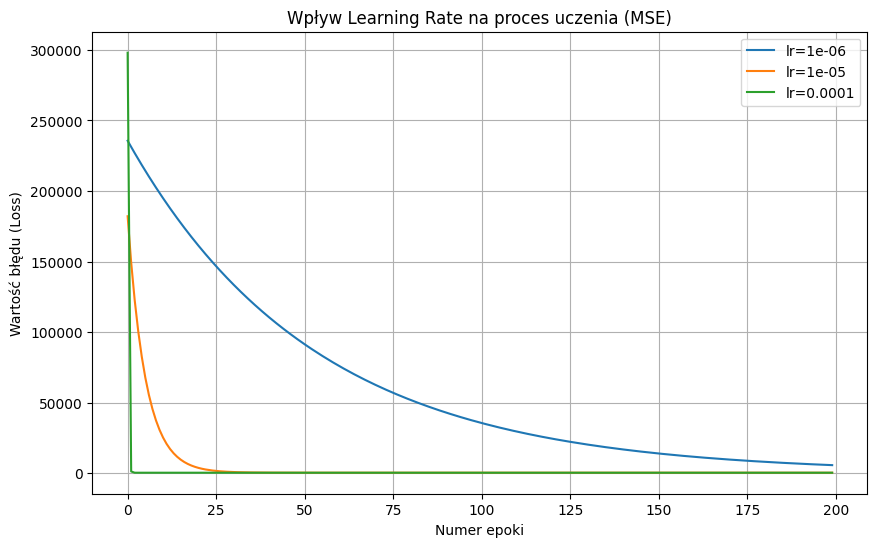

In [4]:
learning_rates = [0.000001, 0.00001, 0.0001]
histories = {}

print("\nEksperyment z learning rate")

for lr in learning_rates:
    model_exp = keras.Sequential([keras.layers.Dense(1, input_shape=(1,))])

    opt = keras.optimizers.SGD(learning_rate=lr)
    model_exp.compile(optimizer=opt, loss='mse')

    hist_exp = model_exp.fit(X, y, epochs=200, verbose=0)
    histories[lr] = hist_exp.history['loss']

plt.figure(figsize=(10, 6))

for lr, loss_values in histories.items():
    plt.plot(loss_values, label=f'lr={lr}')
plt.title('Wpływ Learning Rate na proces uczenia (MSE)')
plt.xlabel('Numer epoki')
plt.ylabel('Wartość błędu (Loss)')
plt.legend()
plt.grid(True)
plt.show()

1. Najlepszy learning rate: 0.0001 (największy z badanych), bo pozwala najszybciej zminimalizować błąd. Krzywa błędu spada najbardziej stromo."
2. Gdy lr jest za mały (np. 0.000001) Model uczy się bardzo wolno.
Błąd maleje, ale po 200 epokach wciąż jest bardzo wysoki w porównaniu do większego lr, co oznacza, że sieć nie zdążyła się nauczyć zależności w wyznaczonym czasie
3. Zbieżność: lr=0.0001 osiąga akceptowalny poziom błędu znacznie szybciej niż pozostałe.